In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/metadata.csv
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2580.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2617.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2794.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2696.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2585.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2637.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2537.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torchvision import models
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# Define Image Transformations with Augmentation for Training
data_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [5]:
# Define Transformations for Validation and Testing (No Augmentation)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [6]:
# Load EyePACS Dataset
data_dir = "/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg"
train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=data_augmentation)
val_dataset = datasets.ImageFolder(root=f"{data_dir}/validation", transform=transform)
test_dataset = datasets.ImageFolder(root=f"{data_dir}/test", transform=transform)

In [7]:
# Create Data Loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [8]:
# Load Pretrained ResNet50 with Dropout
class ResNet50WithDropout(nn.Module):
    def __init__(self, pretrained=True, num_classes=2, dropout_rate=0.5):
        super(ResNet50WithDropout, self).__init__()
        self.model = models.resnet50(pretrained=pretrained)
        num_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = ResNet50WithDropout(pretrained=True, num_classes=2, dropout_rate=0.5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(model)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


ResNet50WithDropout(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(


In [9]:
# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [10]:
# Training Function
def train(model, train_loader, val_loader, epochs=10):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix(loss=running_loss / total, acc=100.0 * correct / total)

        train_loss = running_loss / len(train_loader)
        train_acc = 100.0 * correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        val_acc, val_loss = validate(model, val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model, "best_resnet50_model.pth")

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

    # Save final model
    torch.save(model, "final_resnet50_model.pth")
    print("Final model saved as final_resnet50_model.pth")

    return train_losses, val_losses, train_accuracies, val_accuracies

# Validation Function
def validate(model, val_loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100.0 * correct / total
    return val_acc, val_loss

# Train the model
train_losses, val_losses, train_accuracies, val_accuracies = train(model, train_loader, val_loader, epochs=10)


Epoch 1/10: 100%|██████████| 250/250 [01:49<00:00,  2.29it/s, acc=83, loss=0.012]   


Epoch 1: Train Loss=0.3839, Train Acc=83.00%, Val Loss=0.2614, Val Acc=89.87%


Epoch 2/10: 100%|██████████| 250/250 [01:43<00:00,  2.42it/s, acc=89, loss=0.00857]  


Epoch 2: Train Loss=0.2742, Train Acc=88.96%, Val Loss=0.1966, Val Acc=92.86%


Epoch 3/10: 100%|██████████| 250/250 [01:43<00:00,  2.42it/s, acc=90.7, loss=0.0073] 


...

Epoch 8: Train Loss=0.1228, Train Acc=95.29%, Val Loss=0.1612, Val Acc=94.81%


Epoch 9/10: 100%|██████████| 250/250 [01:43<00:00,  2.42it/s, acc=95.8, loss=0.00355]


Epoch 9: Train Loss=0.1136, Train Acc=95.79%, Val Loss=0.1658, Val Acc=93.90%


Epoch 10/10: 100%|██████████| 250/250 [01:43<00:00,  2.41it/s, acc=96.3, loss=0.00321]


Epoch 10: Train Loss=0.1026, Train Acc=96.31%, Val Loss=0.1805, Val Acc=93.38%
Final model saved as final_resnet50_model.pth


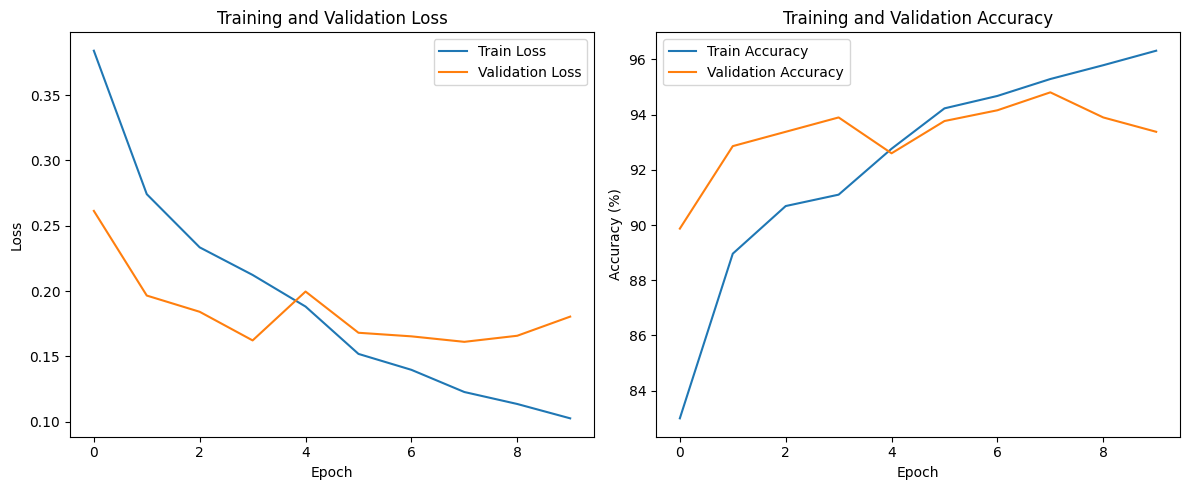

In [12]:
import matplotlib.pyplot as plt
# Plot Training and Validation Metrics
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [13]:
# Test Function
def test(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    test_acc = 100.0 * correct / total
    print(f"Test Accuracy: {test_acc:.2f}%")
    return all_labels, all_preds

# Load the entire model
model_path = "/kaggle/working/best_resnet50_model.pth"  # Path to the saved model
loaded_model = torch.load(model_path)  # Load the entire model
loaded_model = loaded_model.to(device)  # Move to the correct device

# Test the loaded model
labels, preds = test(loaded_model, test_loader)

<ipython-input-13-a341c5032b18>:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model = torch.load(model_path)  # Load the entire model
Testing: 100%|██████████| 25

Test Accuracy: 92.86%


Classification Report:

              precision    recall  f1-score   support

         NRG       0.92      0.94      0.93       385
          RG       0.93      0.92      0.93       385

    accuracy                           0.93       770
   macro avg       0.93      0.93      0.93       770
weighted avg       0.93      0.93      0.93       770



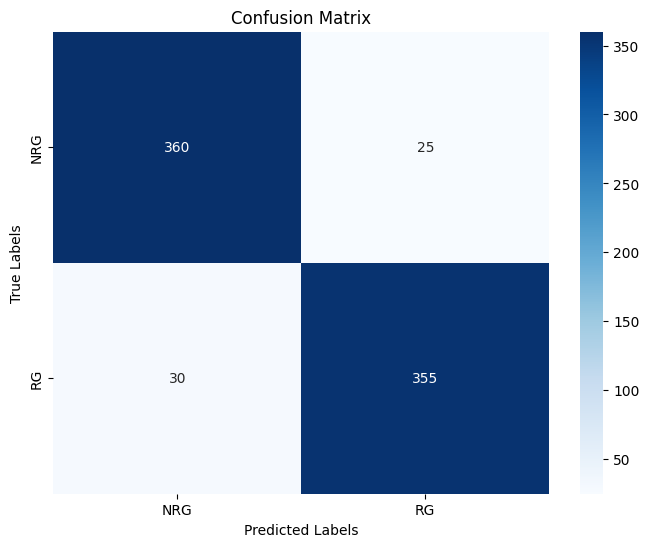

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
# Generate Classification Report and Confusion Matrix
def generate_reports(labels, preds, class_names):
    print("Classification Report:\n")
    print(classification_report(labels, preds, target_names=class_names))

    conf_matrix = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


# Generate reports
class_names = test_dataset.classes
generate_reports(labels, preds, class_names)

In [15]:
from PIL import Image
import numpy as np

# Function to Test Model on Custom Images
def test_on_custom_images(model, image_paths, class_names):
    model.eval()

    for image_path in image_paths:
        image = Image.open(image_path).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = output.max(1)

        print(f"Image: {image_path} | Predicted Class: {class_names[predicted.item()]}")


# Test on Custom Images
custom_image_paths = ["/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/test/NRG/EyePACS-TRAIN-NRG-2890.jpg", "/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/test/RG/EyePACS-TRAIN-RG-2891.jpg"]
test_on_custom_images(model, custom_image_paths, class_names)

Image: /kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/test/NRG/EyePACS-TRAIN-NRG-2890.jpg | Predicted Class: NRG
Image: /kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/test/RG/EyePACS-TRAIN-RG-2891.jpg | Predicted Class: RG
